In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import shap
import os

shap.initjs()

In [9]:
df = pd.read_csv('../data/processed/train_features.csv')

TARGET = "Sales"
FEATURES = df.columns.tolist()
FEATURES.remove("Sales")
FEATURES.remove("Customers")

df = df.sort_values(['Year', 'Week']).reset_index(drop=True)

split_idx = int(len(df) * 0.85)
val_df = df.iloc[split_idx:].copy()

X_val = val_df[FEATURES]
y_val = val_df[TARGET]

model = lgb.Booster(model_file='../models/lgb_model.txt')

print(f"Validation rows: {len(val_df):,}")
print(f"Model loaded: {model.num_trees()} trees")

Validation rows: 126,651
Model loaded: 998 trees


In [10]:
preds = model.predict(X_val)
preds = np.maximum(preds, 0)

val_df['Predicted'] = preds
val_df['Residual'] = val_df['Sales'] - val_df['Predicted']
val_df['AbsError'] = val_df['Residual'].abs()
val_df['PctError'] = (val_df['Residual'] / val_df["Sales"]).abs() * 100

def rmspe(y_true, y_pred):
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

rmspe_score = rmspe(y_val.values, preds)

print(f"RMSPE:          {rmspe_score:.4f}")
print(f"Mean abs error: {val_df['AbsError'].mean():.0f}")
print(f"Median pct err: {val_df['PctError'].median():.1f}%")

RMSPE:          0.1852
Mean abs error: 872
Median pct err: 9.7%


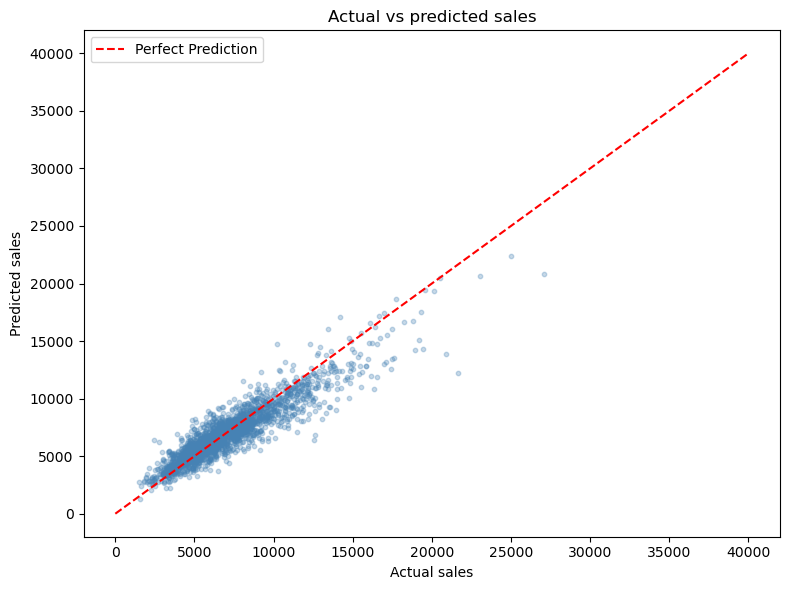

In [17]:
os.makedirs('../images', exist_ok=True)

sample = val_df.sample(2000, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(sample['Sales'], sample['Predicted'], alpha=0.3, s=10, color='steelblue')
plt.plot([0, 40000], [0, 40000], 'r--', linewidth=1.5, label='Perfect Prediction')
plt.xlabel("Actual sales")
plt.ylabel("Predicted sales")
plt.title("Actual vs predicted sales")
plt.legend()
plt.tight_layout()
plt.savefig("../images/10_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()


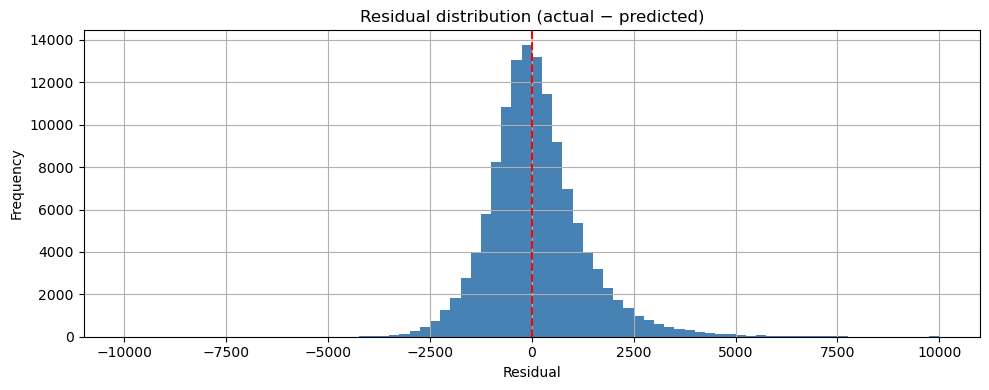

Mean residual: 116
Std residual:  1224


In [13]:
plt.figure(figsize=(10,4))
val_df['Residual'].clip(-10000, 10000).hist(bins=80, color='steelblue')
plt.axvline(0, color='red', linewidth=1.5, linestyle='--')
plt.title("Residual distribution (actual − predicted)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../images/11_residual_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean residual: {val_df['Residual'].mean():.0f}")
print(f"Std residual:  {val_df['Residual'].std():.0f}")

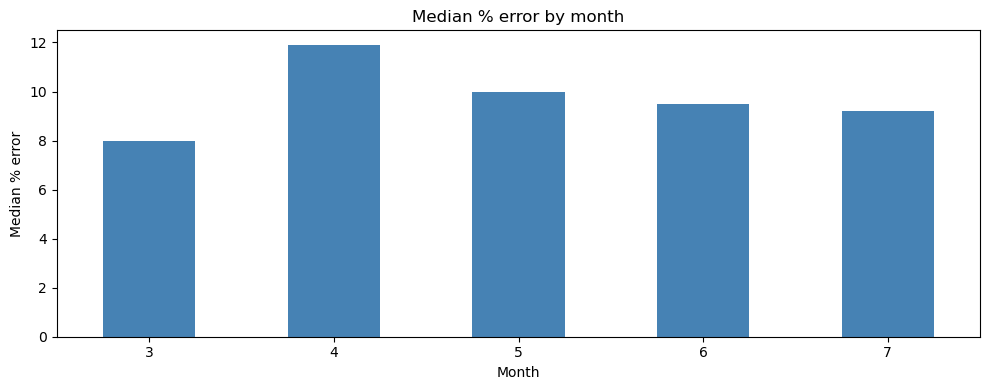

Month
3     8.0
4    11.9
5    10.0
6     9.5
7     9.2
Name: PctError, dtype: float64


In [14]:
monthly_error = val_df.groupby("Month")["PctError"].median().round(1)

monthly_error.plot(kind="bar", figsize=(10, 4), color="steelblue")
plt.title("Median % error by month")
plt.xlabel("Month")
plt.ylabel("Median % error")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/12_error_by_month.png", dpi=150, bbox_inches="tight")
plt.show()

print(monthly_error)

In [15]:
store_error = val_df.groupby('Store')['PctError'].median().sort_values(ascending=False)

print("Top 10 hardest stores to predict:")
print(store_error.head(10).round(1))

print(f"\nEasiest 10 stores:")
print(store_error.tail(10).round(1))

Top 10 hardest stores to predict:
Store
198    50.0
488    44.8
770    43.3
970    38.9
286    38.2
839    36.4
642    35.8
585    33.3
897    32.9
675    31.3
Name: PctError, dtype: float64

Easiest 10 stores:
Store
76      5.6
251     5.6
968     5.6
1071    5.5
726     5.5
528     5.5
388     5.4
718     5.4
109     5.2
1020    4.7
Name: PctError, dtype: float64


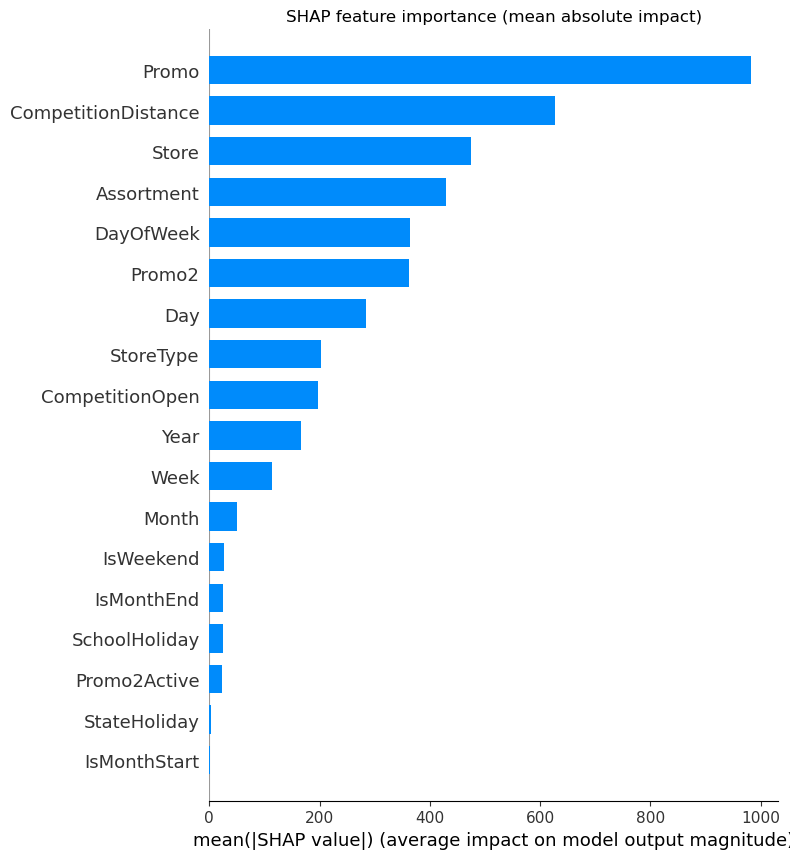

In [18]:
explainer = shap.TreeExplainer(model)

shap_sample = X_val.sample(500, random_state=42)
shap_values = explainer.shap_values(shap_sample)

shap.summary_plot(
    shap_values,
    shap_sample,
    plot_type='bar',
    show=False
)
plt.title("SHAP feature importance (mean absolute impact)")
plt.tight_layout()
plt.savefig("../images/13_shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()


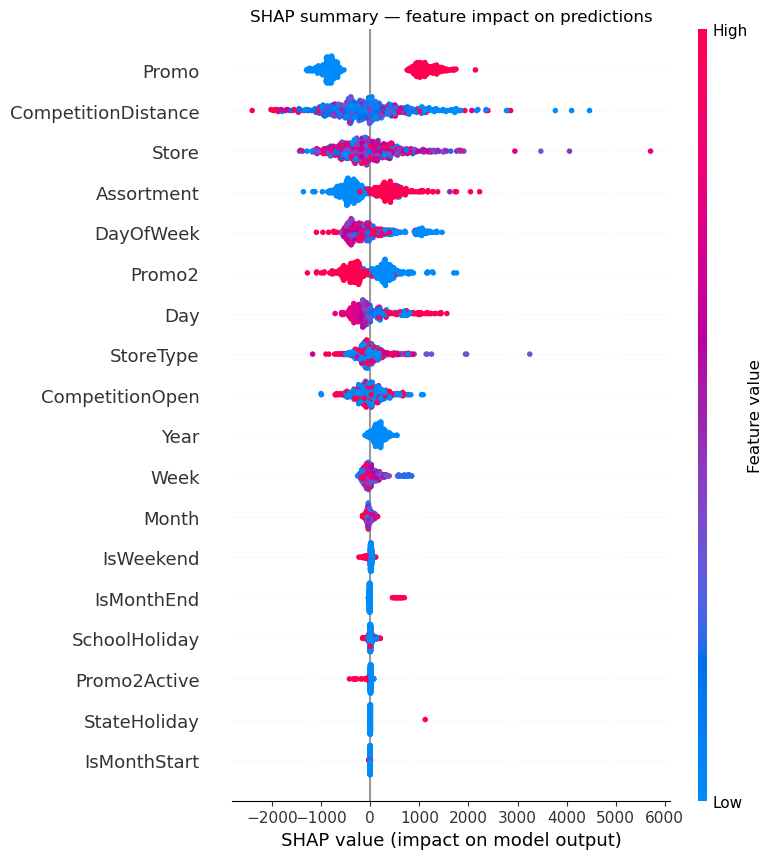

In [19]:
shap.summary_plot(
    shap_values,
    shap_sample,
    show=False
)
plt.title("SHAP summary — feature impact on predictions")
plt.tight_layout()
plt.savefig("../images/14_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## Business Interpretation

### What the model learned

**Store identity is everything.**
The single most important predictor is which store it is.
Each store has its own baseline sales level that the model learns individually.
This means the model has effectively memorised a per-store average and adjusts from there.

**Promotions are the strongest actionable lever.**
Promo is the top feature the business can actually control.
EDA showed an 81% average sales lift on promo days — the model confirms this is real.

**Competition matters more than expected.**
CompetitionDistance and CompetitionOpen both rank highly.
Stores with longer-established nearby competitors have adapted their baseline —
the model captures this through the CompetitionOpen feature we engineered.

**Time patterns are reliable.**
Month, Week, and DayOfWeek all contribute meaningfully.
December and Monday/Sunday spikes the model saw in EDA are being used predictively.

### Where the model struggles

**Store 198 has 50% median error** — nearly 10x worse than the best store.
This store likely has unusual events, refurbishments, or external factors not in the dataset.

**April has the highest monthly error (11.9%).**
Easter timing shifts year to year — sometimes April, sometimes March.
A fixed month feature cannot fully capture a floating holiday.
A "days to Easter" feature would likely improve this.

### How to improve the model

1. Increase num_boost_round to 2000 — model had not converged at 998 trees
2. Add per-store mean sales as a feature — would directly encode store baseline
3. Add a "days to nearest holiday" feature — would fix the floating Easter problem
4. Investigate store 198 and the other high-error stores for data anomalies

## Evaluation Summary

| Metric | Value |
|--------|-------|
| RMSPE | 0.1852 |
| Mean absolute error | £872 |
| Median % error | 9.7% |
| Mean residual | 116 (near zero — no systematic bias) |
| Best store error | 4.7% (Store 1020) |
| Worst store error | 50.0% (Store 198) |

Model performs well on average but has significant variance across stores.
Next steps: increase num_boost_round, add store-level features, engineer holiday proximity.